<a href="https://colab.research.google.com/github/Rumeysakeskin/Image-Classification-InceptionV3/blob/main/trasfer_learning_Inception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install keras


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy==1.21.6

   ---------------------------------------- 0.0/14.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.0 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/14.0 MB 5.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.9/14.0 MB 4.9 MB/s eta 0:00:03
   ----------- ---------------------------- 3.9/14.0 MB 4.9 MB/s eta 0:00:03
   ------------- -------------------------- 4.7/14.0 MB 4.9 MB/s eta 0:00:02
   ---------------- ----------------------- 5.8/14.0 MB 4.9 MB/s eta 0:00:02
   ------------------- -------------------- 6.8/14.0 MB 4.9 MB/s eta 0:00:02
   ---------------------- ----------------- 7.9/14.0 MB 4.9 MB/s eta 0:00:02
   ------------------------- -------------- 8.9/14.0 MB 4.9 MB/s eta 0:00:02
   ---------------------------- ----------- 10.0/14.0 MB 4.9 MB/s eta 0:00:01
   ------------------------------- -------- 11.0/14.0 MB 4.9 MB/s eta 0:00:01
   ---------------------------------- ----- 12.1/14.0 MB 4.9 MB/s eta 0:00:01
   

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.2.0 requires numpy<2,>=1.22.4; python_version < "3.11", but you have numpy 1.21.6 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 1.21.6 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.21.6 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install opencv-python


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install np_utils

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56463 sha256=35e56183a0d70b866388ad51d734bf366ecdd2f6e0af3ace2f15a05bd9e0a4d2
  Stored in directory: c:\users\akhil\appdata\local\pip\cache\wheels\65\07\4b\1c96f437e1bec60b3d2acd0b81d0a7969505f5251efbb5a060
Successfully built np_utils
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#keep
import keras,os
import numpy as np
import tensorflow as tf
import cv2
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Sequential , load_model , Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D , Flatten, Dropout, GlobalAveragePooling2D 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import np_utils
from tensorflow.keras import applications
from tensorflow.keras import optimizers


c:\Users\AKHIL\AppData\Local\Programs\Python\Python39\lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [ ]:
#keep
with tf.device('/gpu:0'):
    pass

In [ ]:
#keep
data_dir = r"C:\Users\AKHIL\Desktop\Final Dataset\Train\Skin"
valid_dir = r"C:\Users\AKHIL\Desktop\Final Dataset\Valid\Skin"
image_generator = ImageDataGenerator(rescale=1./255)  # Rescale pixel values to [0, 1]

# Set up the training data generator
train_data_dir = image_generator.flow_from_directory(
    batch_size=32,
    directory=data_dir,  # Path to your training images
    shuffle=True,
    target_size=(224, 224),  # Resize all images to 224x224
    class_mode='categorical'  # For multi-class classification
)

# Set up the validation data generator
validation_dir = image_generator.flow_from_directory(
    batch_size=32,
    directory=valid_dir,  # Path to your validation images
    shuffle=True,
    target_size=(224, 224),  # Resize all images to 224x224
    class_mode='categorical'  # For multi-class classification
)

Found 900 images belonging to 3 classes.
Found 87 images belonging to 3 classes.


In [ ]:
#keep
base_model = applications.inception_v3.InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation= 'softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step


In [ ]:
#keep
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,808,931 (83.19 MB)

 Trainable params: 21,774,499 (83.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
# import tensorflow as tf

# checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     'skin_disease_model.h5',
#     monitor='val_loss',
#     mode='min',
#     save_best_only=False,  # Change to True if you only want to save the best model
#     save_freq='epoch',  # Replaces deprecated 'period' argument
#     verbose=1
# )


ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=skin_disease_model.h5

In [29]:
# earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
#                           min_delta=0,
#                           patience=3,
#                           verbose=1,
#                           restore_best_weights=True
#                           )

In [30]:
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
#                               factor=0.2,
#                               patience=3,
#                               verbose=1,
#                               min_delta=0.0001)

In [ ]:
#keep
from tensorflow.keras.callbacks import ModelCheckpoint

# Set the path to save the model after each epoch
checkpoint = ModelCheckpoint(
    'skin_disease_model_epoch_{epoch:02d}.keras',  # Save with epoch number and use .keras format
    monitor='val_loss',  # Monitor validation loss (you can change this if you want to monitor something else)
    save_best_only=False,  # Save the model at the end of every epoch, not just the best one
    mode='min',  # Minimize the validation loss (you can change it depending on the metric you're monitoring)
    verbose=1
)

epochs = 50
batch_size = 32

history = model.fit(
    train_data_dir,
    steps_per_epoch=train_data_dir.samples // batch_size,
    validation_data=validation_dir,
    validation_steps=validation_dir.samples // batch_size,
    epochs=epochs,
    callbacks=[checkpoint]  # Use the checkpoint callback
)

# Optional: save the model at the end of the final epoch as well
model.save('skin_disease_model_final.keras')  # Save the final model in .keras format


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7886 - loss: 0.5621
Epoch 1: saving model to skin_disease_model_epoch_01.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - accuracy: 0.7893 - loss: 0.5613 - val_accuracy: 0.9375 - val_loss: 0.4051
Epoch 2/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 1:49 4s/step - accuracy: 0.9062 - loss: 0.4617
Epoch 2: saving model to skin_disease_model_epoch_02.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9062 - loss: 0.4617 - val_accuracy: 0.9531 - val_loss: 0.3972
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8714 - loss: 0.4654
Epoch 3: saving model to skin_disease_model_epoch_03.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.8716 - loss: 0.4647 - val_accuracy: 0.9531 - val_loss: 0.3608
Epoch 4/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 1:46 4s/step - accuracy: 0.7500 - loss: 0.6124
Epoch 4: saving model to skin_disease_model_epoch_04.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - accuracy: 0.7500 - loss: 0.6124 - va

In [ ]:
#keep
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

# Load your .keras model
model = load_model('skin_disease_model_epoch_50.keras')

# Set image dimensions (make sure to match your model input shape)
img_width, img_height = 224, 224  # For example, change this to match your model's expected input size

# Set the path to your test dataset
test_data_dir = r'C:\Users\AKHIL\Desktop\Final Dataset\Test\Skin'

# Prepare the lists to hold the image data and labels
image_data = []
labels = []

# Function to load and preprocess images manually
def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)  # Read the image using OpenCV
    img = cv2.resize(img, target_size)  # Resize the image to the target size
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB (OpenCV loads as BGR)
    img = img.astype(np.float32) / 255.0  # Normalize the image to [0, 1]
    return img

# Iterate over the directories (class subdirectories)
for class_name in os.listdir(test_data_dir):
    class_dir = os.path.join(test_data_dir, class_name)
    if os.path.isdir(class_dir):
        # Iterate over the images in the class directory
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = preprocess_image(img_path, target_size=(img_width, img_height))
            image_data.append(img)
            labels.append(class_name)  # The label is the name of the folder (class name)

# Convert lists to numpy arrays
image_data = np.array(image_data)
labels = np.array(labels)

# Convert class labels to one-hot encoding
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_one_hot = to_categorical(labels_encoded)

# Evaluate the model on the manually loaded test dataset
loss, accuracy = model.evaluate(image_data, labels_one_hot, batch_size=32)

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9869 - loss: 0.1038
Test Loss: 0.11526812613010406
Test Accuracy: 0.9857142567634583


In [ ]:
# callbacks = [checkpoint]
# epochs = 10
# batch_size = 32

In [ ]:
# history = model.fit(
#     train_data_dir,
#     steps_per_epoch=train_data_dir.samples // batch_size,
#     validation_data=validation_dir, 
#     validation_steps=validation_dir.samples // batch_size,
#     epochs=epochs,
#     callbacks=callbacks
# )

# model.save('skin_disease_model.h5')


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3549 - loss: 1.2541
Epoch 1: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.3554 - loss: 1.2522 - val_accuracy: 0.3551 - val_loss: 1.1846
Epoch 2/10
 1/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 1.0000 - loss: 0.5290

c:\Users\DELL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 659ms/step - accuracy: 1.0000 - loss: 0.5290 - val_accuracy: 0.3608 - val_loss: 1.1800
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4969 - loss: 1.0037
Epoch 3: saving model to skin_disease_model.h5


...

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 691ms/step - accuracy: 0.6562 - loss: 0.6734 - val_accuracy: 0.7159 - val_loss: 0.7467
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7031 - loss: 0.7399
Epoch 7: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.7040 - loss: 0.7391 - val_accuracy: 0.8068 - val_loss: 0.6210
Epoch 8/10
 1/26 ━━━━━━━━━━━━━━━━━━━━ 2:19 6s/step - accuracy: 0.6250 - loss: 0.8134
Epoch 8: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 757ms/step - accuracy: 0.6250 - loss: 0.8134 - val_accuracy: 0.8068 - val_loss: 0.6203
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7391 - loss: 0.6764
Epoch 9: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.7400 - loss: 0.6754 - val_accuracy: 0.8722 - val_loss: 0.5369
Epoch 10/10
 1/26 ━━━━━━━━━━━━━━━━━━━━ 1:49 4s/step - accuracy: 0.7812 - loss: 0.6505
Epoch 10: saving model to skin_disease_model.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 585ms/step - accuracy: 0.7812 - loss: 0.6505 - val_accuracy: 0.8722 - val_loss: 0.5360


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


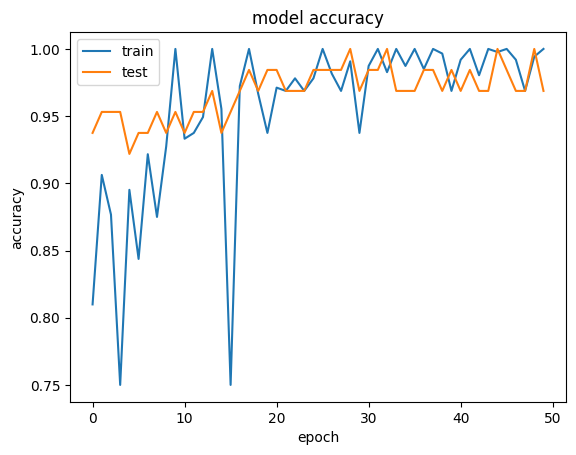

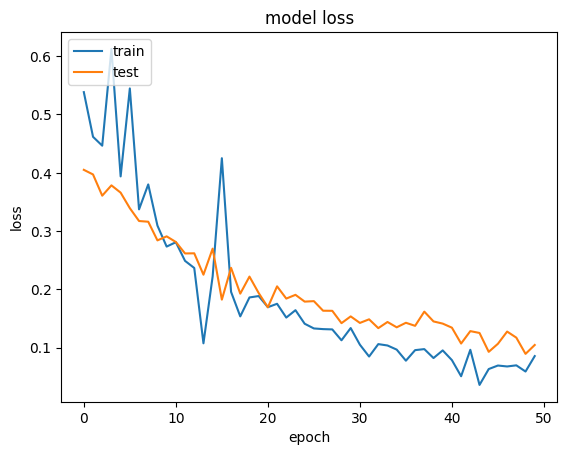

In [ ]:
#keep
import matplotlib.pyplot as plt
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.show()

In [6]:
import cv2
import numpy as np

# Function to load and preprocess images manually
def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)  # Read the image using OpenCV
    img = cv2.resize(img, target_size)  # Resize the image to the target size
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB (OpenCV loads as BGR)
    img = img.astype(np.float32) / 255.0  # Normalize the image to [0, 1]
    return img

# Load and preprocess the image
img = preprocess_image(r"C:\Users\AKHIL\Desktop\Final Dataset\Test\Skin\Carcinoma\Carcinoma_136.jpg")

# Reshape the image to add a batch dimension (1, height, width, channels)
img = np.expand_dims(img, axis=0)

# Make the prediction
prediction = model.predict(img)

# Print the prediction result
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.00592222 0.98139924 0.01267859]]


In [7]:
# Assuming the model outputs probabilities for each class
predicted_class = np.argmax(prediction, axis=1)  # Get the index of the predicted class
print(f"Predicted Class Index: {predicted_class}")


Predicted Class Index: [1]
